In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/ecommerce_messy.csv')

In [98]:
df.dropna()
df = df.dropna()

In [99]:
df['customer_id'] = df['customer_id'].astype(int)

In [100]:
df['category'] = df['category'].str.capitalize()
df['category'] = df['category'].replace('Cloth', 'Clothing')
df['category'] = df['category'].replace('Elec', 'Electronics')
df['category'] = df['category'].replace('Home', 'Home & garden')

In [101]:
df['payment_method'] = df['payment_method'].str.capitalize()
df['payment_method']=df['payment_method'].str.replace('Cc','Unknow')

In [102]:
df['city'] = df['city'].str.capitalize()
df['city']=df['city'].str.replace('La','Los angeles')
df['city']=df['city'].str.replace('Ny','New york')

In [103]:
df['clean_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce',
    format='mixed',
    dayfirst=True
)


In [104]:
df["clean_date"] = pd.to_datetime(df["clean_date"], errors="coerce")
df.drop("order_date", axis=1, inplace=True)
df.rename(columns={"clean_date": "order_date"}, inplace=True)

In [105]:
df['clean_date'] = pd.to_datetime(
    df['delivery_date'],
    errors='coerce',
    format='mixed',
    dayfirst=True
)


In [106]:
df["clean_date"] = pd.to_datetime(df["clean_date"], errors="coerce")
df.drop("delivery_date", axis=1, inplace=True)
df.rename(columns={"clean_date": "delivery_date"}, inplace=True)

boxplot:


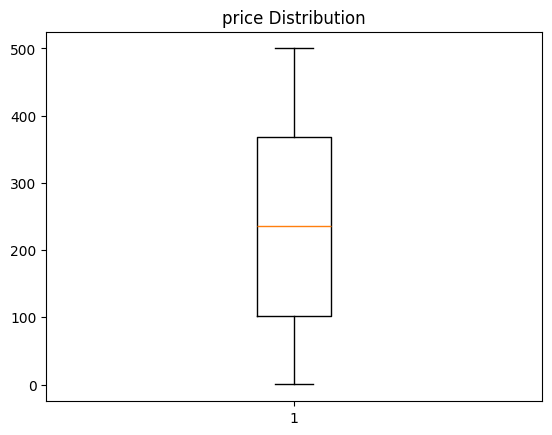

In [107]:
df['price']=df['price'].str.replace('$','')
df['price']=df['price'].str.replace('bucks','')
df['price'] = df['price'].astype(float)
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df= df[(df["price"] >= lower) & (df["price"] <= upper)]
#-----
print('boxplot:')
plt.boxplot(df["price"])
plt.title("price Distribution")
plt.show()

boxplot:


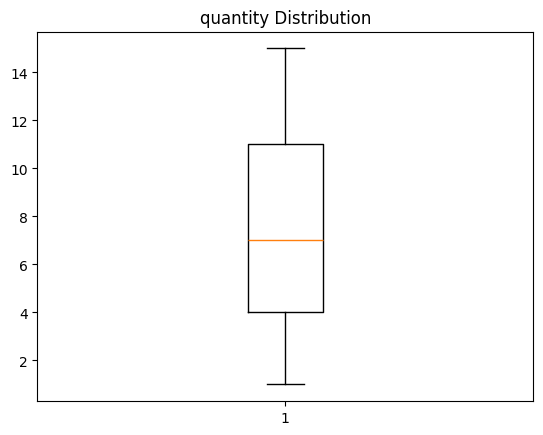

In [108]:
df['quantity']=df['quantity'].str.replace('-','')

df['quantity']=df['quantity'].str.replace('two','2')
df['quantity'] = df['quantity'].astype(int)
Q1 = df["quantity"].quantile(0.25)
Q3 = df["quantity"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df= df[(df["quantity"] >= lower) & (df["quantity"] <= upper)]
#-----
print('boxplot:')
plt.boxplot(df["quantity"])
plt.title("quantity Distribution")
plt.show()

In [109]:
price_sum = df.groupby('category')['price'].sum().sort_values(ascending=False)
print(price_sum)

category
Electronics      879233.30
Clothing         862246.52
Home & garden    592590.64
Tech             294421.74
Toys             285147.56
Name: price, dtype: float64


Total Price by Category:


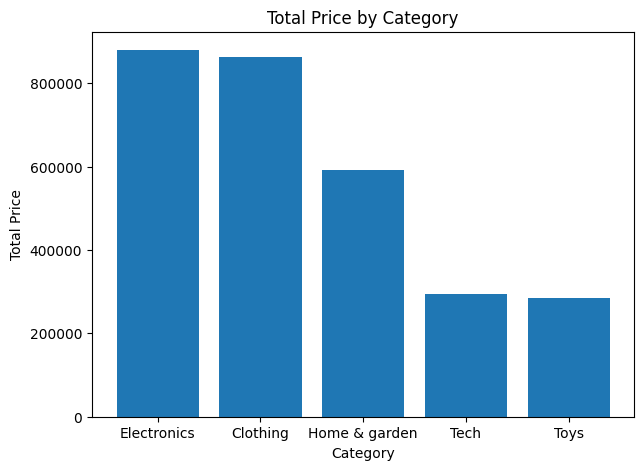

In [110]:
print('Total Price by Category:')
plt.figure(figsize=(7, 5))
plt.bar(price_sum.index, price_sum.values)
plt.xlabel('Category')
plt.ylabel('Total Price')
plt.title('Total Price by Category')


plt.show()

In [111]:
category_sum1 = df.groupby('category')['quantity'].sum().sort_values(ascending=False)
print(category_sum1)

category
Electronics      28178
Clothing         26727
Home & garden    18683
Tech              9509
Toys              9075
Name: quantity, dtype: int64


total quantity in each category:


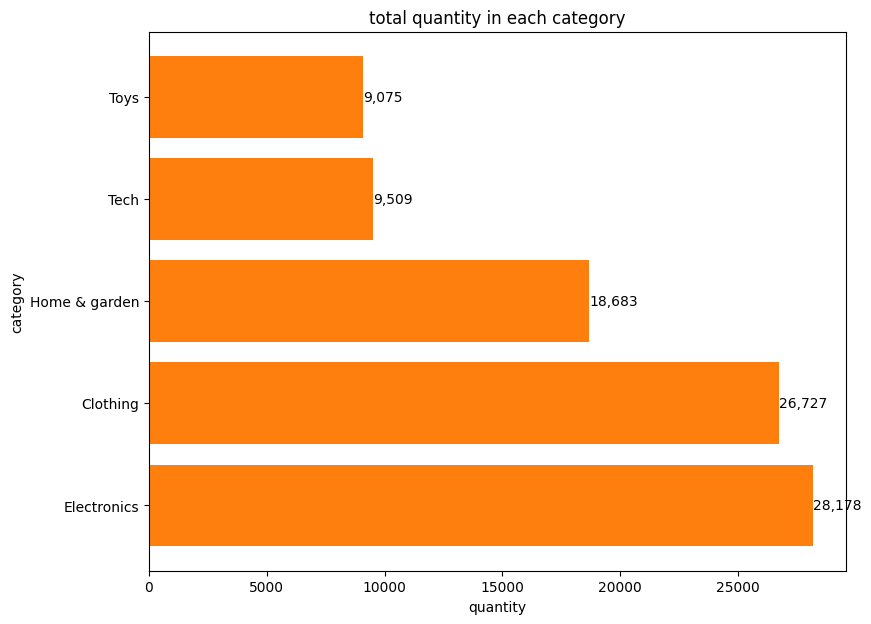

In [112]:
print("total quantity in each category:")
plt.figure(figsize=(9, 7))
plt.barh(category_sum1.index, category_sum1.values)
plt.xlabel("quantity")
plt.ylabel("category")
plt.title("total quantity in each category")
bars = plt.barh(category_sum1.index, category_sum1.values)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va='center'
    )

plt.show()

In [113]:
city_sum2 = df.groupby('city')['price'].sum().sort_values(ascending=False)
print(city_sum2)

city
New york       1079868.27
Los angeles     738902.24
Chicago         371827.15
Boston          363590.88
Houston         359451.22
Name: price, dtype: float64


total price in each city:


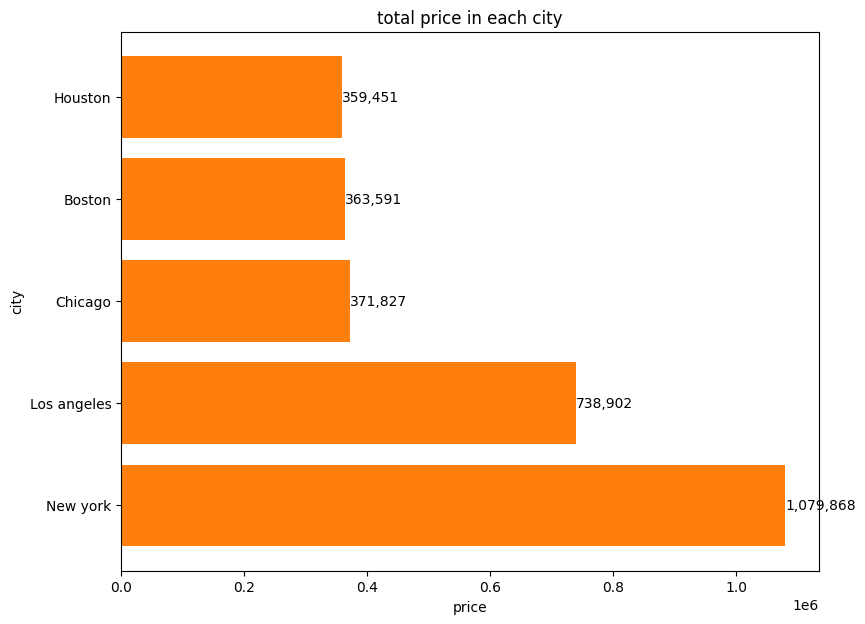

In [114]:
print("total price in each city:")
plt.figure(figsize=(9, 7))
plt.barh(city_sum2.index, city_sum2.values)
plt.xlabel("price")
plt.ylabel("city")
plt.title("total price in each city")
bars = plt.barh(city_sum2.index, city_sum2.values)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va='center'
    )
plt.show()

In [115]:
df.head(20)

,order_id,customer_id,product_name,category,price,quantity,payment_method,city,order_date,delivery_date
0,ORD-83015,2647,Product_3,Clothing,121.92,9,Credit card,New york,2019-08-18,2021-09-05
4,ORD-44260,948,Product_894,Toys,435.04,10,Paypal,New york,2023-09-18,2020-10-22
6,ORD-29534,3146,Product_821,Clothing,30.43,2,Unknow,Los angeles,2020-04-13,2019-03-09
7,ORD-39537,3149,Product_72,Electronics,16.79,8,Credit card,Los angeles,2019-09-07,2022-02-20
9,ORD-20217,1373,Product_127,Home & garden,448.41,9,Paypal,New york,NaT,2023-01-12
10,ORD-88256,3746,Product_724,Electronics,447.27,5,Cash on delivery,Los angeles,2020-11-21,2023-04-03
11,ORD-48306,1020,Product_391,Clothing,348.18,9,Cash on delivery,Houston,NaT,NaT
12,ORD-95339,275,Product_126,Home & garden,341.08,9,Paypal,Houston,2019-12-28,2019-11-26
13,ORD-72963,2233,Product_979,Clothing,92.28,10,Paypal,Los angeles,2020-10-07,2022-11-06
15,ORD-74085,2563,Product_287,Clothing,33.00,2,Paypal,Los angeles,2018-03-21,2023-06-18


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12191 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        12191 non-null  object        
 1   customer_id     12191 non-null  int64         
 2   product_name    12191 non-null  object        
 3   category        12191 non-null  object        
 4   price           12191 non-null  float64       
 5   quantity        12191 non-null  int64         
 6   payment_method  12191 non-null  object        
 7   city            12191 non-null  object        
 8   order_date      10942 non-null  datetime64[ns]
 9   delivery_date   11009 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 1.0+ MB


In [117]:
df.isnull().sum()

,0
order_id,0
customer_id,0
product_name,0
category,0
price,0
quantity,0
payment_method,0
city,0
order_date,1249
delivery_date,1182


In [120]:
df.to_csv("clean_data.csv", index=False)
from google.colab import files

df.to_csv("clean_data.csv", index=False)

files.download("clean_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>